In [1]:
#Import Libraries & Load Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv("Dataset .csv")

# Display the first few rows
data[['Restaurant Name', 'Aggregate rating', 'Votes']].head()


,Restaurant Name,Aggregate rating,Votes
0,Le Petit Souffle,4.8,314
1,Izakaya Kikufuji,4.5,591
2,Heat - Edsa Shangri-La,4.4,270
3,Ooma,4.9,365
4,Sambo Kojin,4.8,229


In [3]:
#Identify Restaurant Chains

In [4]:
# Count how many times each restaurant name appears
chain_counts = data['Restaurant Name'].value_counts()

# Filter only restaurant names that appear more than once
restaurant_chains = chain_counts[chain_counts > 1]

# Display top 10 chains
print("Top 10 Restaurant Chains:")
print(restaurant_chains.head(10))


Top 10 Restaurant Chains:
Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64


In [5]:
#Visualize the Top Restaurant Chains

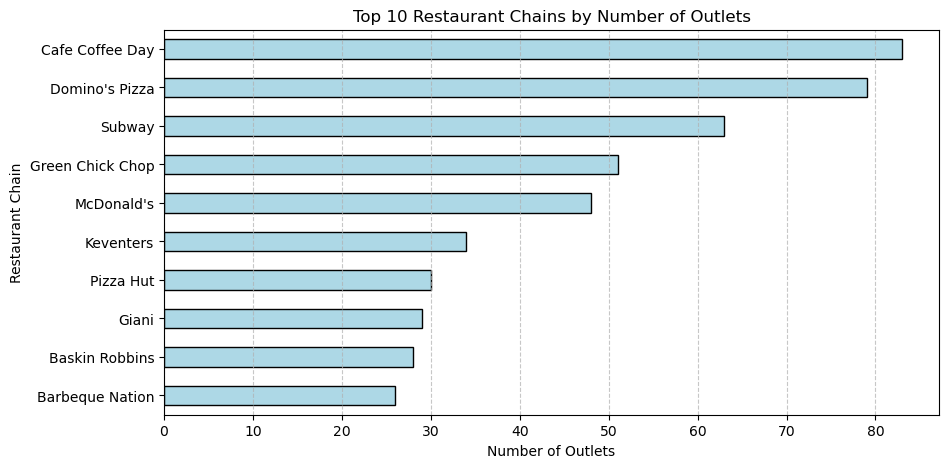

In [7]:
plt.figure(figsize=(10,5))
restaurant_chains.head(10).sort_values().plot(kind='barh', color='lightblue', edgecolor='black')
plt.title('Top 10 Restaurant Chains by Number of Outlets')
plt.xlabel('Number of Outlets')
plt.ylabel('Restaurant Chain')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


In [8]:
#Analyze Ratings and Popularity of Chains

In [9]:
# Group by restaurant name to calculate mean rating and votes
chain_analysis = data.groupby('Restaurant Name')[['Aggregate rating', 'Votes']].mean()

# Add a column for outlet count
chain_analysis['Outlet Count'] = data['Restaurant Name'].value_counts()

# Filter only restaurant chains (more than one outlet)
chain_analysis = chain_analysis[chain_analysis['Outlet Count'] > 1]

# Sort by rating (top-rated chains)
chain_analysis_sorted = chain_analysis.sort_values(by='Aggregate rating', ascending=False)

# Display top 10
print("Top 10 Highest Rated Restaurant Chains:")
print(chain_analysis_sorted.head(10))


Top 10 Highest Rated Restaurant Chains:
                           Aggregate rating   Votes  Outlet Count
Restaurant Name                                                  
Talaga Sampireun                      4.900  1838.0             3
AB's Absolute Barbecues               4.850  1575.5             2
Silantro Fil-Mex                      4.850   682.0             2
AB's - Absolute Barbecues             4.825  3350.0             4
Naturals Ice Cream                    4.800  1547.0             2
Gymkhana                              4.700   164.0             2
The Cheesecake Factory                4.650  1505.0             2
Dishoom                               4.600   634.5             2
Garota de Ipanema                     4.600    29.5             2
Chili's                               4.580  1631.2             5


In [10]:
#Visualization — Top Chains by Rating

C:\Users\DELL\AppData\Local\Temp\ipykernel_52844\1628646472.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


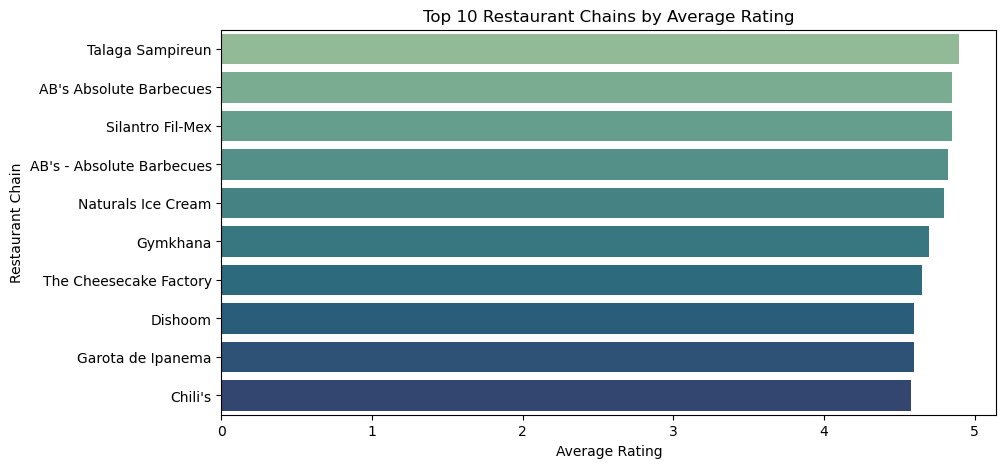

In [11]:
plt.figure(figsize=(10,5))
sns.barplot(
    x='Aggregate rating',
    y=chain_analysis_sorted.head(10).index,
    data=chain_analysis_sorted.head(10),
    palette='crest'
)
plt.title('Top 10 Restaurant Chains by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Restaurant Chain')
plt.show()


In [12]:
#Visualization — Top Chains by Popularity (Votes)

C:\Users\DELL\AppData\Local\Temp\ipykernel_52844\2280480537.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


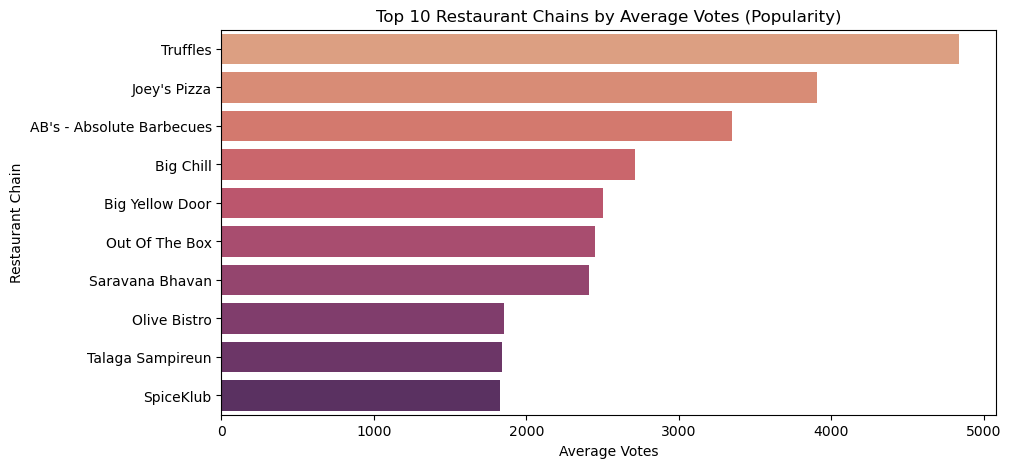

In [13]:
top_chains_votes = chain_analysis.sort_values(by='Votes', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x='Votes',
    y=top_chains_votes.index,
    data=top_chains_votes,
    palette='flare'
)
plt.title('Top 10 Restaurant Chains by Average Votes (Popularity)')
plt.xlabel('Average Votes')
plt.ylabel('Restaurant Chain')
plt.show()


In [14]:
#Summary of Insights

In [15]:
most_outlets = restaurant_chains.idxmax()
highest_rated_chain = chain_analysis_sorted.index[0]
most_popular_chain = top_chains_votes.index[0]

print("SUMMARY")
print(f"• Most widespread chain: {most_outlets}")
print(f"• Highest rated chain: {highest_rated_chain}")
print(f"• Most popular (highest votes) chain: {most_popular_chain}")


SUMMARY
• Most widespread chain: Cafe Coffee Day
• Highest rated chain: Talaga Sampireun
• Most popular (highest votes) chain: Truffles
